In [1]:
!python --version

Python 3.10.5


In [2]:
!python run_decision_transformer.py

Traceback (most recent call last):
  File "/gpfs/data/fs72297/jklotz/programming/cloned_repos/forked_repos_for_master_thesis/d3rlpy/experiments/exp01_original_dt/run_decision_transformer.py", line 6, in <module>
    import gymnasium as gym
ModuleNotFoundError: No module named 'gymnasium'


In [4]:
%python run_decision_transformer.py

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

#experiment of insterest is the one with 30552 at the end
path = "/gpfs/data/fs72297/jklotz/programming/cloned_repos/forked_repos_for_master_thesis/d3rlpy/experiments/exp01_original_dt/d3rlpy_logs/DT_hopper-medium-expert-v2_1_20250621130552/"
    

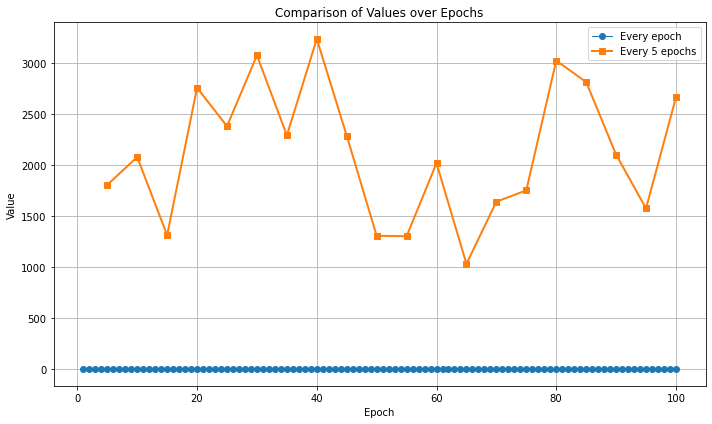

In [10]:
# Read the files, no header
df1 = pd.read_csv(f"{path}loss.csv", header=None)
df2 = pd.read_csv(f"{path}environment.csv", header=None)

# Optional: Assign column names for readability
df1.columns = ['epoch', 'steps', 'value1']
df2.columns = ['epoch', 'steps', 'value2']

# Plot
plt.figure(figsize=(10,6))

plt.plot(df1['epoch'], df1['value1'], label='Every epoch', marker='o', linewidth=1)
plt.plot(df2['epoch'], df2['value2'], label='Every 5 epochs', marker='s', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Comparison of Values over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

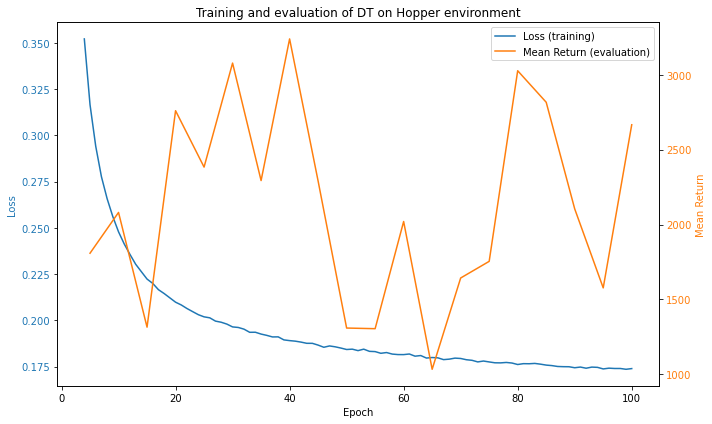

In [13]:
# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(10, 6))

df1 = df1[df1['epoch'] >= 4]
df2 = df2[df2['epoch'] >= 4]

# Plot first file (left y-axis)
line1 = ax1.plot(df1['epoch'], df1['value1'], label='Loss (training)', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create second y-axis (right)
ax2 = ax1.twinx()
line2 = ax2.plot(df2['epoch'], df2['value2'], label='Mean Return (evaluation)', color='tab:orange')
ax2.set_ylabel('Mean Return', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Training and evaluation of DT on Hopper environment')
plt.tight_layout()
plt.show()